In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from imblearn.over_sampling import SMOTE

In [19]:
def calculate_vpd(temperature, humidity):
    """Calculate Vapor Pressure Deficit (VPD) given temperature (°C) and relative humidity (%)."""
    es = 0.6108 * np.exp((17.27 * temperature) / (temperature + 237.3))  # Saturation vapor pressure in kPa
    ea = es * (humidity / 100.0)  # Actual vapor pressure in kPa
    vpd = es - ea  # VPD in kPa
    return vpd

def get_part_of_day(hour):
    """Phân loại giờ trong ngày thành các buổi có ý nghĩa nông nghiệp."""
    if 5 <= hour <= 10: return 'Morning'
    if 11 <= hour <= 15: return 'Midday'  # Giai đoạn nắng gắt, nhu cầu nước cao nhất
    if 16 <= hour <= 19: return 'Afternoon'
    return 'Night' # Ban đêm, nhu cầu nước thấp

In [20]:
#---- Load datasets ----#


climate_df = pd.read_csv('GreenhouseClimate.csv', low_memory=False)
weather_df = pd.read_csv('Weather.csv', low_memory=False)
grodan_df = pd.read_csv('GrodanSens.csv', low_memory=False)

#------ Data frame merged ----#

merged_df = pd.merge(climate_df, weather_df, on='%time', how='inner')
full_df = pd.merge(merged_df, grodan_df, on='%time', how='inner')

print("Hợp nhất thành công!")
print(f"  - Bộ dữ liệu tổng hợp có {full_df.shape[0]} dòng và {full_df.shape[1]} cột.")

Hợp nhất thành công!
  - Bộ dữ liệu tổng hợp có 47809 dòng và 66 cột.


In [21]:
print("\nBắt đầu làm sạch và chuẩn hóa...")
# 3.1. Chuyển đổi cột '%time' sang định dạng datetime chuẩn
# Định dạng thời gian trong Excel là số ngày kể từ mốc '1899-12-30'
full_df['datetime'] = pd.to_datetime(full_df['%time'], unit='D', origin='1899-12-30')

full_df.set_index('datetime', inplace=True)
full_df.drop('%time', axis=1, inplace=True) # Bỏ cột '%time' cũ

print(" - Đã chuyển đổi và đặt cột thời gian làm index.")



Bắt đầu làm sạch và chuẩn hóa...
 - Đã chuyển đổi và đặt cột thời gian làm index.


In [22]:
env_features = [
    # Từ GreenhouseClimate
    'Tair', 'Rhair', 'CO2air', 'HumDef', 'PipeGrow', 'PipeLow', 'Tot_PAR',
    # Từ Weather
    'Tout', 'Rhout', 'Iglob', 'Windsp', 'RadSum', 'Rain', 'PARout', 'Pyrgeo', 'AbsHumOut',
    # Từ GrodanSens
    'EC_slab1', 'EC_slab2', 'WC_slab1', 'WC_slab2', 't_slab1', 't_slab2',
    # Cột target
    'Cum_irr'
]
print(f"  - Giữ lại {len(env_features)} cột môi trường và cột target.")
clean_df = full_df[env_features].copy()


  - Giữ lại 23 cột môi trường và cột target.


In [23]:
for col in clean_df.columns:
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

print("  - Chuyển đổi sang kiểu số hoàn tất.")

  - Chuyển đổi sang kiểu số hoàn tất.


In [24]:
#-------------------------------------------------------------
#----- Nan processing ----#
print(f"  - Số dòng TRƯỚC khi loại bỏ NaN: {len(clean_df)}")
clean_df.dropna(subset=env_features[:-1], inplace=True) 
print(f"  - Số dòng SAU khi loại bỏ NaN: {len(clean_df)}")

  - Số dòng TRƯỚC khi loại bỏ NaN: 47809
  - Số dòng SAU khi loại bỏ NaN: 45460


In [25]:
#-------------------------------------------------------------------------
#----- Data feature engineering ----#

#Create time-based features

clean_df['VPD'] = calculate_vpd(clean_df['Tair'], clean_df['Rhair'])  #Tính VPD từ nhiệt độ và độ ẩm tương đối

clean_df['hour'] = clean_df.index.hour
clean_df['dayofweek'] = clean_df.index.dayofweek

# Create rolling features

WINDOW_SIZE_1H = 12 # 1 hour window (5 min intervals)

clean_df['Tair_1h_avg'] = clean_df['Tair'].rolling(window=WINDOW_SIZE_1H).mean()  #Nhiệt độ không khí trung bình trong 1 giờ
clean_df['Iglob_1h_sum'] = clean_df['Iglob'].rolling(window=WINDOW_SIZE_1H).sum()  #Tong bức xạ mặt trời trong 1 giờ

#Create lag features

LAG_30MIN = 6  # 30 minutes lag (5 min intervals)

clean_df['WC_slab1_30m_ago'] = clean_df['WC_slab1'].shift(LAG_30MIN)  #Độ ẩm slab 1 cách đây 30 phút
clean_df['Tair_30m_diff'] = clean_df['Tair'].diff(LAG_30MIN) #Sự thay đổi nhiệt độ không khí trong 30 phút

clean_df['PAR_x_HumDef'] = clean_df['Tot_PAR'] * clean_df['HumDef']

WINDOW_2H = 24
clean_df['Tair_2h_max'] = clean_df['Tair'].rolling(WINDOW_2H).max() #Nhiệt độ không khí cao nhất trong 2 giờ
clean_df['WC_slab1_2h_min'] = clean_df['WC_slab1'].rolling(WINDOW_2H).min() #Độ ẩm slab 1 thấp nhất trong 2 giờ

# Kết hợp ảnh hưởng của nhiệt độ và bức xạ mặt trời ngoài trời
clean_df['Tair_x_Iglob'] = clean_df['Tair'] * clean_df['Iglob']

clean_df['PartOfDay'] = clean_df['hour'].apply(get_part_of_day)
part_of_day_dummies = pd.get_dummies(clean_df['PartOfDay'], prefix='PartOfDay') #One-hot encoding cho biến phân loại PartOfDay
clean_df = pd.concat([clean_df, part_of_day_dummies], axis=1)
clean_df.drop(['PartOfDay', 'hour'], axis=1, inplace=True)

WINDOW_4H = 48 # 4 giờ * 12 mẫu/giờ = 48 mẫu
clean_df['WC_slab1_4h_avg'] = clean_df['WC_slab1'].rolling(WINDOW_4H).mean()
# Tính toán "tốc độ thay đổi" của giá trị trung bình 4 giờ trong 30 phút qua
clean_df['WC_slab1_4h_avg_diff'] = clean_df['WC_slab1_4h_avg'].diff(LAG_30MIN)
print("  - Đã tạo feature xu hướng dài hạn 'WC_slab1_4h_avg_diff'.")
 
print(f"  - Số dòng TRƯỚC khi bỏ NaN từ feature engineering: {len(clean_df)}")
clean_df.dropna(inplace=True) 
print(f"  - Số dòng SAU khi bỏ NaN từ feature engineering: {len(clean_df)}")




  - Đã tạo feature xu hướng dài hạn 'WC_slab1_4h_avg_diff'.
  - Số dòng TRƯỚC khi bỏ NaN từ feature engineering: 45460
  - Số dòng SAU khi bỏ NaN từ feature engineering: 45407


In [26]:
# =============================================================================
# BƯỚC 5: XÁC ĐỊNH BIẾN MỤC TIÊU (TARGET VARIABLE)
# =============================================================================

clean_df['Cum_irr'] = pd.to_numeric(clean_df['Cum_irr'], errors='coerce')
clean_df['Cum_irr'].interpolate(method='time', inplace=True)
clean_df['Cum_irr'].fillna(method='ffill', inplace=True)

irrigation_events = (clean_df['Cum_irr'].diff() > 0)

clean_df['Is_Irrigating'] = irrigation_events.astype(int)


clean_df.drop('Cum_irr', axis=1, inplace=True)
clean_df = clean_df.iloc[1:]
print("\nBiến mục tiêu 'Is_Irrigating' đã được tạo thành công.")

print("\nPhân bổ nhãn của biến mục tiêu:")
print(clean_df['Is_Irrigating'].value_counts(normalize=True))
print("(Đây là bài toán mất cân bằng, số lần 'Không tưới' nhiều hơn 'Tưới' rất nhiều)")



Biến mục tiêu 'Is_Irrigating' đã được tạo thành công.

Phân bổ nhãn của biến mục tiêu:
Is_Irrigating
0    0.928093
1    0.071907
Name: proportion, dtype: float64
(Đây là bài toán mất cân bằng, số lần 'Không tưới' nhiều hơn 'Tưới' rất nhiều)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5224\2393767069.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df['Cum_irr'].interpolate(method='time', inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5224\2393767069.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [27]:
print(clean_df.head())
print(f"\nKích thước cuối cùng: {clean_df.shape}")
new_cols_to_check = ['PartOfDay_Midday', 'PartOfDay_Night', 'WC_slab1_4h_avg_diff']
print(clean_df[new_cols_to_check].head())
clean_df.to_csv('processed_greenhouse_data_clean.csv')
print("\nĐã lưu vào file 'processed_greenhouse_data_clean.csv'")



                               Tair  Rhair  CO2air  HumDef  PipeGrow  PipeLow  \
datetime                                                                        
2019-12-17 13:09:59.903999827  21.9   69.7   748.0     5.8       0.0      0.0   
2019-12-17 13:14:59.712000112  21.9   69.6   735.0     5.9       0.0      0.0   
2019-12-17 13:20:00.384000060  22.1   69.6   725.0     5.9       0.0      0.0   
2019-12-17 13:25:00.191999714  22.1   69.8   722.0     5.9       0.0      0.0   
2019-12-17 13:30:00.000000000  22.4   70.2   709.0     5.9       0.0      0.0   

                               Tot_PAR  Tout  Rhout       Iglob  ...  \
datetime                                                         ...   
2019-12-17 13:09:59.903999827    183.0  13.1   76.6  105.999999  ...   
2019-12-17 13:14:59.712000112    164.0  13.2   76.0   60.000003  ...   
2019-12-17 13:20:00.384000060    191.0  13.3   75.7   84.999997  ...   
2019-12-17 13:25:00.191999714    246.0  13.6   75.2  131.999997  ...   


In [28]:
print("\n Bắt đầu huấn luyện mô hình LightGBM...")

data_df = pd.read_csv('processed_greenhouse_data_clean.csv', index_col='datetime', parse_dates=True)
print(f" - Kích thước bộ dữ liệu đã tải: {data_df.shape}")

y = data_df['Is_Irrigating']
X = data_df.drop('Is_Irrigating', axis=1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"  - Kích thước tập Train: {X_train.shape}")
print(f"  - Kích thước tập Test: {X_test.shape}")
print(f"  - Ngày bắt đầu tập Train: {X_train.index.min()}")
print(f"  - Ngày kết thúc tập Train: {X_train.index.max()}")
print(f"  - Ngày bắt đầu tập Test:  {X_test.index.min()}")
print(f"  - Ngày kết thúc tập Test:  {X_test.index.max()}")


 Bắt đầu huấn luyện mô hình LightGBM...
 - Kích thước bộ dữ liệu đã tải: (45406, 39)
  - Kích thước tập Train: (36324, 38)
  - Kích thước tập Test: (9082, 38)
  - Ngày bắt đầu tập Train: 2019-12-17 13:09:59.903999827
  - Ngày kết thúc tập Train: 2020-04-24 13:50:00.096000172
  - Ngày bắt đầu tập Test:  2020-04-24 13:54:59.903999827
  - Ngày kết thúc tập Test:  2020-05-26 09:35:00.384000060


In [47]:
# #--------------------------------------------------
# #----- SMOTEEN ----#
from imblearn.combine import SMOTEENN

smote = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Phân bổ lớp TRƯỚC khi dùng SMOTEEN:")
print(y_train.value_counts())
print("\nPhân bổ lớp SAU khi dùng SMOTEEN:")
print(y_train_resampled.value_counts())

Phân bổ lớp TRƯỚC khi dùng SMOTEEN:
Is_Irrigating
0    33943
1     2381
Name: count, dtype: int64

Phân bổ lớp SAU khi dùng SMOTEEN:
Is_Irrigating
1    31672
0    25857
Name: count, dtype: int64


In [30]:
#----- Randomized Search for Hyperparameter Tuning ----#

# param_grid = param_grid = {
#     'n_estimators': [400, 700, 1000, 1500],
#     'learning_rate': [0.01, 0.02, 0.05, 0.1],
#     'num_leaves': [20, 31, 40, 50],
#     'max_depth': [-1, 10, 15, 20],
#     'reg_alpha': [0.0, 0.1, 0.5, 1.0], # L1 regularization
#     'reg_lambda': [0.0, 0.1, 0.5, 1.0], # L2 regularization
#     'colsample_bytree': [0.6, 0.8, 1.0], # Tỷ lệ feature sử dụng cho mỗi cây
#     'metric': ['binary_logloss', 'auc']
# }

# f1_scorer = make_scorer(f1_score, pos_label=1)

# lgb_base = lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1, is_unbalance=True)

# random_search = RandomizedSearchCV(
#     estimator=lgb_base,
#     param_distributions=param_grid,
#     n_iter=100,
#     scoring=f1_scorer,
#     cv=3,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )



In [52]:
lgb_clf = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=700,
    learning_rate=0.01,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    is_unbalance=True,
    max_depth=20,
    reg_alpha=1.0,
    colsample_bytree=0.6
)

start_time = time.time()

lgb_clf.fit(X_train_resampled, y_train_resampled)

end_time = time.time()

print(f"\nTinh chỉnh hoàn tất trong {(end_time - start_time):.2f} giây.")





[LightGBM] [Info] Number of positive: 31672, number of negative: 25857
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8425
[LightGBM] [Info] Number of data points in the train set: 57529, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550540 -> initscore=0.202852
[LightGBM] [Info] Start training from score 0.202852

Tinh chỉnh hoàn tất trong 1.67 giây.


In [32]:
# print("\nCác siêu tham số tốt nhất được tìm thấy:")
# print(random_search.best_params_)
# best_model = random_search.best_estimator_


Đánh giá hiệu suất trên tập Test ...

===== ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT (VỚI NGƯỠNG 0.5) =====
                precision    recall  f1-score   support

Không tưới (0)       0.97      0.72      0.83      8198
      Tưới (1)       0.24      0.80      0.36       884

      accuracy                           0.73      9082
     macro avg       0.60      0.76      0.60      9082
  weighted avg       0.90      0.73      0.78      9082

2. Ma trận nhầm lẫn (Confusion Matrix):


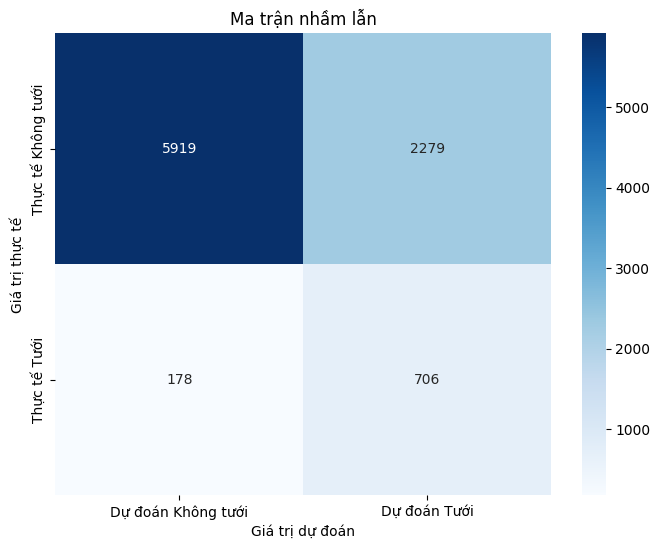

In [53]:
#---------------------------------------------------
#----- Model Evaluation ----#

print("\nĐánh giá hiệu suất trên tập Test ...")

print("\n===== ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT (VỚI NGƯỠNG 0.5) =====")
y_pred_best_default = lgb_clf.predict(X_test)
print(classification_report(y_test, y_pred_best_default, target_names=['Không tưới (0)', 'Tưới (1)']))

print("2. Ma trận nhầm lẫn (Confusion Matrix):")
cm = confusion_matrix(y_test, y_pred_best_default)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dự đoán Không tưới', 'Dự đoán Tưới'],
            yticklabels=['Thực tế Không tưới', 'Thực tế Tưới'])
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.title('Ma trận nhầm lẫn')
plt.show()




In [34]:
# print("\nPhân tích mức độ quan trọng của các đặc trưng...")

# # Lấy ra danh sách các feature và mức độ quan trọng của chúng
# feature_imp = pd.DataFrame(sorted(zip(lgb_clf.feature_importances_, X.columns)),
#                            columns=['Value', 'Feature'])

# # Vẽ biểu đồ top 20 feature quan trọng nhất
# plt.figure(figsize=(10, 8))
# sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(20))
# plt.title('Top 20 Đặc trưng quan trọng nhất')
# plt.xlabel('Mức độ quan trọng')
# plt.ylabel('Tên đặc trưng')
# plt.tight_layout()
# plt.show()

In [55]:
print("\n===== BẮT ĐẦU ĐIỀU CHỈNH NGƯỠNG CHO MÔ HÌNH TỐT NHẤT =====")

# Lấy ra xác suất dự đoán
probabilities_best = lgb_clf.predict_proba(X_test)[:, 1]

# Thử nghiệm các ngưỡng
thresholds = np.arange(0.1, 0.61, 0.05)
results = []
for threshold in thresholds:
    y_pred_new = (probabilities_best > threshold).astype(int)
    recall = recall_score(y_test, y_pred_new, pos_label=1, zero_division=0)
    precision = precision_score(y_test, y_pred_new, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_new, pos_label=1, zero_division=0)
    results.append({'threshold': round(threshold, 2), 'recall': round(recall, 2),
                    'precision': round(precision, 2), 'f1_score': round(f1, 2)})

results_df = pd.DataFrame(results)
print("\nBảng kết quả thử nghiệm ngưỡng:")
print(results_df)

best_threshold_row = results_df.loc[results_df['f1_score'].idxmax()]
best_threshold = best_threshold_row['threshold']
print(f"\nNgưỡng tốt nhất dựa trên F1-score là: {best_threshold}")



===== BẮT ĐẦU ĐIỀU CHỈNH NGƯỠNG CHO MÔ HÌNH TỐT NHẤT =====

Bảng kết quả thử nghiệm ngưỡng:
    threshold  recall  precision  f1_score
0        0.10    0.93       0.18      0.30
1        0.15    0.91       0.20      0.33
2        0.20    0.90       0.22      0.35
3        0.25    0.89       0.22      0.36
4        0.30    0.87       0.23      0.36
5        0.35    0.85       0.23      0.36
6        0.40    0.84       0.23      0.37
7        0.45    0.83       0.23      0.37
8        0.50    0.80       0.24      0.36
9        0.55    0.77       0.24      0.37
10       0.60    0.72       0.24      0.36

Ngưỡng tốt nhất dựa trên F1-score là: 0.4



Báo cáo phân loại cuối cùng (Mô hình tốt nhất + Ngưỡng tốt nhất):
                precision    recall  f1-score   support

Không tưới (0)       0.98      0.70      0.82      8198
      Tưới (1)       0.23      0.84      0.37       884

      accuracy                           0.72      9082
     macro avg       0.60      0.77      0.59      9082
  weighted avg       0.90      0.72      0.77      9082



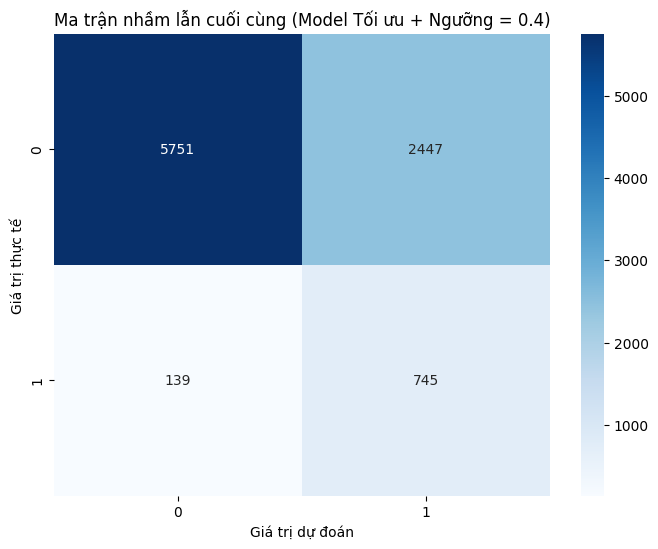

In [56]:
final_predictions = (probabilities_best > best_threshold).astype(int) 
print("\nBáo cáo phân loại cuối cùng (Mô hình tốt nhất + Ngưỡng tốt nhất):")
print(classification_report(y_test, final_predictions, target_names=['Không tưới (0)', 'Tưới (1)']))

# Ma trận nhầm lẫn cuối cùng
cm_final = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.title(f'Ma trận nhầm lẫn cuối cùng (Model Tối ưu + Ngưỡng = {best_threshold})')
plt.show()

In [57]:
import joblib

model_filename = 's.joblib'

joblib.dump(lgb_clf, model_filename)
print(f"\nMô hình đã được lưu vào file '{model_filename}'")

best_threshold_value = best_threshold # Lấy từ bước trước
print(f"Ngưỡng quyết định tốt nhất là: {best_threshold_value}")


Mô hình đã được lưu vào file 's.joblib'
Ngưỡng quyết định tốt nhất là: 0.4
